# Hacia el agua limpia para todos: Parte 1 y Parte 2

**Objetivo de este notebook.** Preparar el dataset Water Potability y entrenar una linea base SVM-RBF clasica bajo el protocolo estricto del nuevo planteamiento:

- imputacion por mediana por clase;
- estandarizacion sin fuga de informacion;
- balanceo de clases por submuestreo en training;
- division estratificada 80/20;
- validacion cruzada estratificada de 5 particiones;
- grilla obligatoria `C in {0.1, 1, 10}` y `gamma in {scale, auto, 0.01}`;
- reporte de exactitud, precision, recall, F1 y matriz de confusion.

Ademas se congela un subconjunto balanceado de 80 muestras para la fase cuantica posterior, con 5 folds balanceados de 8/8 por clase.

## Aprendizajes heredados del proyecto anterior

El README y los artefactos previos sugieren tres reglas para este reinicio:

1. **No seleccionar solo por F1.** Un threshold negativo puede subir F1 al predecir mas muestras como potables, pero tambien aumenta falsos positivos: aguas no potables marcadas como potables.
2. **No comparar poblaciones distintas.** Una QSVM de 80 filas debe compararse contra una SVM entrenada/evaluada sobre esas mismas 80 filas y folds, no contra una SVM entrenada con miles de filas.
3. **Reducir features es una decision tecnica valida.** El estudio previo de estabilidad favorecio 5 variables (`Sulfate`, `ph`, `Solids`, `Chloramines`, `Hardness`). Aqui auditamos 9, 5 y 4 variables con la grilla estricta antes de recomendar el espacio de entrada para QSVM.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

from pathlib import Path
import itertools
import json
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    matthews_corrcoef,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

TARGET = "Potability"
CLASS_LABELS = [0, 1]
CLASS_NAMES = {0: "No potable", 1: "Potable"}

SEEDS = {
    "split": 20260801,
    "feature_cv": 20260803,
    "quantum_sample": 20260805,
    "outer_folds": 20260806,
    "undersample_base": 20260820,
}

C_GRID = [0.1, 1.0, 10.0]
GAMMA_GRID = ["scale", "auto", 0.01]
N_SPLITS = 5
QUANTUM_ROWS = 80

FEATURE_SETS = {
    "raw9": [
        "ph", "Hardness", "Solids", "Chloramines", "Sulfate",
        "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity",
    ],
    "chem5_prev": ["Sulfate", "ph", "Solids", "Chloramines", "Hardness"],
    "chem4_prev": ["Sulfate", "ph", "Solids", "Chloramines"],
    "preview4": ["ph", "Solids", "Conductivity", "Turbidity"],
}


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "water_potability.csv").exists():
            return candidate
    raise FileNotFoundError("No se encontro data/water_potability.csv en la ruta actual ni en sus padres.")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "water_potability.csv"
PREVIOUS_DIR = PROJECT_ROOT / "notebooks" / "Johnny" / "previos_experiments"
ARTIFACT_DIR = PROJECT_ROOT / "notebooks" / "Johnny" / "artifacts_hacia_agua_limpia_partes_1_2"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {DATA_PATH}")
print(f"Artifacts: {ARTIFACT_DIR}")

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\johnn\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Project root: C:\Users\johnn\OneDrive\Documentos\Quanthaton\TuQanes
Dataset: C:\Users\johnn\OneDrive\Documentos\Quanthaton\TuQanes\data\water_potability.csv
Artifacts: C:\Users\johnn\OneDrive\Documentos\Quanthaton\TuQanes\notebooks\Johnny\artifacts_hacia_agua_limpia_partes_1_2


## 1. Carga y contrato del dataset

El dataset original se carga con `source_index` para poder congelar filas y verificar que el subconjunto de 80 no intersecte el holdout.

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.reset_index(names="source_index")

required_columns = set(FEATURE_SETS["raw9"] + [TARGET])
missing_columns = sorted(required_columns - set(df_raw.columns))
if missing_columns:
    raise ValueError(f"Columnas faltantes en el dataset: {missing_columns}")

if not set(df_raw[TARGET].dropna().unique()).issubset({0, 1}):
    raise ValueError("La variable objetivo debe ser binaria con clases 0 y 1.")

contract = {
    "dataset_sha256": sha256_file(DATA_PATH),
    "shape": df_raw.shape,
    "class_counts": df_raw[TARGET].value_counts().sort_index().to_dict(),
    "missing_counts": df_raw.isna().sum().to_dict(),
}

missing_report = (
    df_raw.isna().sum()
    .rename("missing")
    .to_frame()
    .assign(missing_pct=lambda d: d["missing"] / len(df_raw))
    .query("missing > 0")
    .sort_values("missing", ascending=False)
)

class_report = (
    df_raw[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis("Potability")
    .reset_index(name="rows")
)
class_report["share"] = class_report["rows"] / len(df_raw)
class_report["label"] = class_report["Potability"].map(CLASS_NAMES)

print(json.dumps(contract, indent=2))
display(class_report)
display(missing_report)

with (ARTIFACT_DIR / "data_contract.json").open("w", encoding="utf-8") as f:
    json.dump(contract, f, indent=2)

{
  "dataset_sha256": "904004bde729bfe3d2e195f46343bceead09e32a0eb95bb8184e7e20e029b2bf",
  "shape": [
    3276,
    10
  ],
  "class_counts": {
    "0": 1998,
    "1": 1278
  },
  "missing_counts": {
    "ph": 491,
    "Hardness": 0,
    "Solids": 0,
    "Chloramines": 0,
    "Sulfate": 781,
    "Conductivity": 0,
    "Organic_carbon": 0,
    "Trihalomethanes": 162,
    "Turbidity": 0,
    "Potability": 0
  }
}


,Potability,rows,share,label
0,0,1998,0.60989,No potable
1,1,1278,0.39011,Potable


,missing,missing_pct
Sulfate,781,0.238400
ph,491,0.149878
Trihalomethanes,162,0.049451


## 2. Split 80/20 y reglas de preprocesamiento

Reglas aplicadas en todo el notebook:

- se divide antes de imputar, escalar o balancear;
- las medianas por clase se calculan solo con el training de cada fold o con el training completo final;
- el escalador se ajusta solo en training;
- el submuestreo se aplica solo al training, no al holdout;
- el holdout queda reservado para evaluacion final, no para seleccionar hiperparametros.

Nota metodologica: la imputacion por mediana por clase usa la etiqueta para escoger la mediana de entrenamiento correspondiente. Esto replica el enunciado del reto, pero no es directamente desplegable porque en produccion la etiqueta es desconocida.

In [3]:
X_all = df.drop(columns=[TARGET])
y_all = df[TARGET].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=SEEDS["split"],
)

split_report = pd.DataFrame([
    {"split": "train", "rows": len(y_train), "class_0": int((y_train == 0).sum()), "class_1": int((y_train == 1).sum())},
    {"split": "holdout", "rows": len(y_test), "class_0": int((y_test == 0).sum()), "class_1": int((y_test == 1).sum())},
])
split_report["class_1_share"] = split_report["class_1"] / split_report["rows"]

display(split_report)
split_report.to_csv(ARTIFACT_DIR / "train_holdout_split_report.csv", index=False)

,split,rows,class_0,class_1,class_1_share
0,train,2620,1598,1022,0.390076
1,holdout,656,400,256,0.390244


In [4]:
def fit_class_medians(X: pd.DataFrame, y: pd.Series) -> dict:
    y = pd.Series(np.asarray(y, dtype=int), index=X.index)
    by_class = {
        int(cls): X.loc[y == cls].median(numeric_only=True)
        for cls in sorted(pd.unique(y))
    }
    return {"by_class": by_class, "global": X.median(numeric_only=True)}


def transform_class_medians(X: pd.DataFrame, y: pd.Series, stats: dict) -> pd.DataFrame:
    X_imp = X.copy()
    y = pd.Series(np.asarray(y, dtype=int), index=X.index)
    for cls, medians in stats["by_class"].items():
        idx = y == cls
        X_imp.loc[idx] = X_imp.loc[idx].fillna(medians)
    return X_imp.fillna(stats["global"])


def undersample_arrays(X_array: np.ndarray, y: pd.Series | np.ndarray, seed: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    y_array = np.asarray(y, dtype=int)
    rng = np.random.default_rng(seed)
    classes, counts = np.unique(y_array, return_counts=True)
    n_min = int(counts.min())
    keep = []
    for cls in classes:
        cls_idx = np.flatnonzero(y_array == cls)
        keep.extend(rng.choice(cls_idx, size=n_min, replace=False).tolist())
    keep = np.array(sorted(keep), dtype=int)
    return X_array[keep], y_array[keep], keep


def classification_metrics(y_true, y_pred) -> dict:
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)
    tn, fp, fn, tp = [int(v) for v in cm.ravel()]
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def make_splits(y: pd.Series, n_splits: int, seed: int, fold_assignments=None):
    y_reset = pd.Series(np.asarray(y, dtype=int)).reset_index(drop=True)
    if fold_assignments is None:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        return list(skf.split(np.zeros(len(y_reset)), y_reset))
    folds = pd.Series(fold_assignments).reset_index(drop=True).to_numpy()
    return [(np.flatnonzero(folds != fold), np.flatnonzero(folds == fold)) for fold in sorted(np.unique(folds))]


def fit_fold_model(X_tr_raw, y_tr, X_va_raw, y_va, features, C, gamma, balance_training: bool, seed: int):
    medians = fit_class_medians(X_tr_raw[features], y_tr)
    X_tr_imp = transform_class_medians(X_tr_raw[features], y_tr, medians)
    X_va_imp = transform_class_medians(X_va_raw[features], y_va, medians)

    scaler = StandardScaler().fit(X_tr_imp)
    X_tr_scaled = scaler.transform(X_tr_imp)
    X_va_scaled = scaler.transform(X_va_imp)

    if balance_training:
        X_fit, y_fit, _ = undersample_arrays(X_tr_scaled, y_tr, seed=seed)
    else:
        X_fit, y_fit = X_tr_scaled, np.asarray(y_tr, dtype=int)

    clf = SVC(kernel="rbf", C=C, gamma=gamma)
    clf.fit(X_fit, y_fit)
    pred = clf.predict(X_va_scaled)
    score = clf.decision_function(X_va_scaled)
    return clf, pred, score


def cross_validated_oof(
    X_raw: pd.DataFrame,
    y: pd.Series,
    features: list[str],
    C: float,
    gamma,
    n_splits: int = N_SPLITS,
    seed: int = SEEDS["feature_cv"],
    balance_training: bool = True,
    fold_assignments=None,
):
    X_reset = X_raw.reset_index(drop=True)
    y_reset = pd.Series(np.asarray(y, dtype=int)).reset_index(drop=True)
    source_index = X_reset["source_index"] if "source_index" in X_reset.columns else pd.Series(range(len(X_reset)))

    oof_pred = np.empty(len(y_reset), dtype=int)
    oof_score = np.empty(len(y_reset), dtype=float)
    fold_rows = []

    for fold_number, (tr_idx, va_idx) in enumerate(make_splits(y_reset, n_splits, seed, fold_assignments)):
        _, pred, score = fit_fold_model(
            X_reset.iloc[tr_idx],
            y_reset.iloc[tr_idx],
            X_reset.iloc[va_idx],
            y_reset.iloc[va_idx],
            features,
            C,
            gamma,
            balance_training=balance_training,
            seed=SEEDS["undersample_base"] + fold_number,
        )
        oof_pred[va_idx] = pred
        oof_score[va_idx] = score
        row = {"fold": fold_number, "C": C, "gamma": gamma, "n_train": len(tr_idx), "n_valid": len(va_idx)}
        row.update(classification_metrics(y_reset.iloc[va_idx], pred))
        fold_rows.append(row)

    oof_df = pd.DataFrame({
        "source_index": source_index,
        "y_true": y_reset,
        "decision_score": oof_score,
        "y_pred": oof_pred,
    })
    return pd.DataFrame(fold_rows), oof_df


def cross_validate_grid(
    X_raw: pd.DataFrame,
    y: pd.Series,
    features: list[str],
    C_grid: list[float] = C_GRID,
    gamma_grid: list = GAMMA_GRID,
    n_splits: int = N_SPLITS,
    seed: int = SEEDS["feature_cv"],
    balance_training: bool = True,
    fold_assignments=None,
):
    summary_rows = []
    all_fold_rows = []
    for C, gamma in itertools.product(C_grid, gamma_grid):
        fold_df, _ = cross_validated_oof(
            X_raw,
            y,
            features,
            C,
            gamma,
            n_splits=n_splits,
            seed=seed,
            balance_training=balance_training,
            fold_assignments=fold_assignments,
        )
        summary = {"C": C, "gamma": gamma}
        for metric in ["accuracy", "precision", "recall", "f1", "specificity", "balanced_accuracy", "mcc"]:
            summary[f"{metric}_mean"] = float(fold_df[metric].mean())
            summary[f"{metric}_std"] = float(fold_df[metric].std(ddof=1))
        summary_rows.append(summary)
        all_fold_rows.append(fold_df)
    return pd.DataFrame(summary_rows), pd.concat(all_fold_rows, ignore_index=True)


def fit_final_svm(X_train, y_train, X_eval, y_eval, features, C, gamma, balance_training=True):
    medians = fit_class_medians(X_train[features], y_train)
    X_train_imp = transform_class_medians(X_train[features], y_train, medians)
    X_eval_imp = transform_class_medians(X_eval[features], y_eval, medians)

    scaler = StandardScaler().fit(X_train_imp)
    X_train_scaled = scaler.transform(X_train_imp)
    X_eval_scaled = scaler.transform(X_eval_imp)

    if balance_training:
        X_fit, y_fit, keep = undersample_arrays(X_train_scaled, y_train, seed=SEEDS["undersample_base"])
    else:
        X_fit, y_fit, keep = X_train_scaled, np.asarray(y_train, dtype=int), np.arange(len(y_train))

    clf = SVC(kernel="rbf", C=C, gamma=gamma)
    clf.fit(X_fit, y_fit)

    eval_pred = clf.predict(X_eval_scaled)
    eval_score = clf.decision_function(X_eval_scaled)
    train_score = clf.decision_function(X_train_scaled)

    metrics = classification_metrics(y_eval, eval_pred)
    metrics.update({
        "C": C,
        "gamma": gamma,
        "train_rows_before_balance": int(len(y_train)),
        "train_rows_after_balance": int(len(y_fit)),
        "eval_rows": int(len(y_eval)),
    })
    bundle = {
        "model": clf,
        "scaler": scaler,
        "medians": medians,
        "train_scores": train_score,
        "eval_scores": eval_score,
        "eval_pred": eval_pred,
        "balance_keep_positions": keep,
    }
    return metrics, bundle


def choose_threshold_max_f1(y_true, decision_scores) -> tuple[float, dict]:
    y_true = np.asarray(y_true, dtype=int)
    decision_scores = np.asarray(decision_scores, dtype=float)
    best_threshold = 0.0
    best_metrics = classification_metrics(y_true, decision_scores >= 0.0)
    for threshold in np.unique(decision_scores):
        candidate_metrics = classification_metrics(y_true, decision_scores >= threshold)
        if candidate_metrics["f1"] > best_metrics["f1"]:
            best_threshold = float(threshold)
            best_metrics = candidate_metrics
    return best_threshold, best_metrics


def assign_balanced_folds(y: pd.Series, n_splits: int, seed: int) -> np.ndarray:
    y_reset = pd.Series(np.asarray(y, dtype=int)).reset_index(drop=True)
    folds = np.empty(len(y_reset), dtype=int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fold, (_, valid_idx) in enumerate(skf.split(np.zeros(len(y_reset)), y_reset)):
        folds[valid_idx] = fold
    return folds


def select_score_quantile_subset(y_pool: pd.Series, scores: np.ndarray, n_per_class: int) -> list[int]:
    y_array = np.asarray(y_pool, dtype=int)
    selected = []
    for cls in CLASS_LABELS:
        cls_positions = np.flatnonzero(y_array == cls)
        ordered = cls_positions[np.argsort(scores[cls_positions])]
        pick_positions = np.linspace(0, len(ordered) - 1, n_per_class).round().astype(int)
        chosen = list(dict.fromkeys(ordered[pick_positions].tolist()))
        if len(chosen) < n_per_class:
            for candidate in ordered:
                if candidate not in chosen:
                    chosen.append(int(candidate))
                if len(chosen) == n_per_class:
                    break
        selected.extend(chosen[:n_per_class])
    return sorted(selected)

## 3. Auditoria de features con SVM-RBF y CV estricta

Se evalua la grilla requerida en cuatro espacios de variables. La seleccion se hace por F1 medio de CV, con `balanced_accuracy` y `mcc` como desempates tecnicos.

In [5]:
feature_cv_summaries = []
feature_cv_folds = []

for feature_set_name, features in FEATURE_SETS.items():
    print(f"Evaluando {feature_set_name} ({len(features)} features): {features}")
    summary_df, fold_df = cross_validate_grid(
        X_train_raw,
        y_train,
        features,
        balance_training=True,
    )
    summary_df.insert(0, "feature_set", feature_set_name)
    summary_df.insert(1, "n_features", len(features))
    summary_df.insert(2, "features", "|".join(features))
    fold_df.insert(0, "feature_set", feature_set_name)
    feature_cv_summaries.append(summary_df)
    feature_cv_folds.append(fold_df)

feature_cv_summary = pd.concat(feature_cv_summaries, ignore_index=True)
feature_cv_fold_metrics = pd.concat(feature_cv_folds, ignore_index=True)
feature_cv_summary = feature_cv_summary.sort_values(
    ["f1_mean", "balanced_accuracy_mean", "mcc_mean"], ascending=False
).reset_index(drop=True)

feature_cv_summary.to_csv(ARTIFACT_DIR / "feature_cv_summary.csv", index=False)
feature_cv_fold_metrics.to_csv(ARTIFACT_DIR / "feature_cv_fold_metrics.csv", index=False)

display(feature_cv_summary[[
    "feature_set", "n_features", "C", "gamma",
    "accuracy_mean", "precision_mean", "recall_mean", "f1_mean",
    "specificity_mean", "balanced_accuracy_mean", "mcc_mean",
]].head(12))

Evaluando raw9 (9 features): ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']


Evaluando chem5_prev (5 features): ['Sulfate', 'ph', 'Solids', 'Chloramines', 'Hardness']


Evaluando chem4_prev (4 features): ['Sulfate', 'ph', 'Solids', 'Chloramines']


Evaluando preview4 (4 features): ['ph', 'Solids', 'Conductivity', 'Turbidity']


,feature_set,n_features,C,gamma,accuracy_mean,precision_mean,recall_mean,f1_mean,specificity_mean,balanced_accuracy_mean,mcc_mean
0,chem5_prev,5,10.0,scale,0.641603,0.536154,0.601846,0.566642,0.667098,0.634472,0.264628
1,chem5_prev,5,10.0,auto,0.637786,0.531400,0.602817,0.564519,0.660212,0.631514,0.258456
2,raw9,9,10.0,scale,0.621756,0.512226,0.602846,0.553426,0.633932,0.618389,0.231906
3,raw9,9,10.0,auto,0.620992,0.511350,0.603826,0.553347,0.632053,0.617940,0.230959
4,chem5_prev,5,1.0,auto,0.645802,0.545069,0.561722,0.551538,0.699638,0.630680,0.260771
5,raw9,9,1.0,scale,0.634733,0.529052,0.572482,0.549582,0.674585,0.623533,0.244060
6,chem5_prev,5,1.0,scale,0.643511,0.542275,0.557814,0.548102,0.698389,0.628102,0.255737
7,raw9,9,1.0,auto,0.632824,0.526764,0.570526,0.547440,0.672702,0.621614,0.240243
8,chem5_prev,5,0.1,auto,0.625191,0.519579,0.519603,0.518285,0.692729,0.606166,0.212696
9,chem5_prev,5,0.1,scale,0.625191,0.519748,0.517642,0.517309,0.693981,0.605812,0.212178


## 4. Evaluacion en holdout reservado

Para cada espacio de features se toma solo su mejor configuracion por CV y se evalua una vez en el holdout 80/20. El holdout no decide hiperparametros.

In [6]:
best_by_feature = (
    feature_cv_summary
    .sort_values(["feature_set", "f1_mean", "balanced_accuracy_mean", "mcc_mean"], ascending=[True, False, False, False])
    .groupby("feature_set", as_index=False)
    .head(1)
)

holdout_rows = []
final_bundles = {}
for row in best_by_feature.itertuples(index=False):
    features = FEATURE_SETS[row.feature_set]
    metrics, bundle = fit_final_svm(
        X_train_raw,
        y_train,
        X_test_raw,
        y_test,
        features,
        row.C,
        row.gamma,
        balance_training=True,
    )
    metrics.update({
        "feature_set": row.feature_set,
        "n_features": len(features),
        "features": "|".join(features),
        "cv_f1_mean": row.f1_mean,
        "cv_balanced_accuracy_mean": row.balanced_accuracy_mean,
        "cv_mcc_mean": row.mcc_mean,
    })
    holdout_rows.append(metrics)
    final_bundles[row.feature_set] = bundle

holdout_metrics = pd.DataFrame(holdout_rows).sort_values(
    ["cv_f1_mean", "cv_balanced_accuracy_mean", "cv_mcc_mean"], ascending=False
).reset_index(drop=True)
holdout_metrics.to_csv(ARTIFACT_DIR / "feature_holdout_metrics.csv", index=False)

display(holdout_metrics[[
    "feature_set", "n_features", "C", "gamma",
    "accuracy", "precision", "recall", "f1",
    "specificity", "balanced_accuracy", "mcc",
    "tn", "fp", "fn", "tp", "cv_f1_mean",
]])

strict_best = feature_cv_summary.iloc[0]
STRICT_FEATURE_SET = strict_best["feature_set"]
STRICT_FEATURES = FEATURE_SETS[STRICT_FEATURE_SET]
STRICT_C = float(strict_best["C"])
STRICT_GAMMA = strict_best["gamma"]

print("Modelo estricto seleccionado por CV:")
print({
    "feature_set": STRICT_FEATURE_SET,
    "features": STRICT_FEATURES,
    "C": STRICT_C,
    "gamma": STRICT_GAMMA,
    "cv_f1_mean": float(strict_best["f1_mean"]),
})

,feature_set,n_features,C,gamma,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,tn,fp,fn,tp,cv_f1_mean
0,chem5_prev,5,10.0,scale,0.664634,0.565693,0.605469,0.584906,0.7025,0.653984,0.304614,281,119,101,155,0.566642
1,raw9,9,10.0,scale,0.640244,0.534483,0.605469,0.567766,0.6625,0.633984,0.263205,265,135,101,155,0.553426
2,chem4_prev,4,1.0,scale,0.650915,0.548736,0.593750,0.570356,0.6875,0.640625,0.277769,275,125,104,152,0.515691
3,preview4,4,10.0,0.01,0.460366,0.394850,0.718750,0.509695,0.2950,0.506875,0.014787,118,282,72,184,0.493859


Modelo estricto seleccionado por CV:
{'feature_set': 'chem5_prev', 'features': ['Sulfate', 'ph', 'Solids', 'Chloramines', 'Hardness'], 'C': 10.0, 'gamma': 'scale', 'cv_f1_mean': 0.5666423731828814}


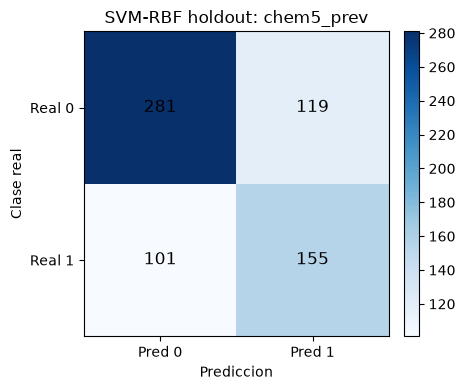

In [7]:
strict_bundle = final_bundles[STRICT_FEATURE_SET]
strict_holdout_predictions = pd.DataFrame({
    "source_index": X_test_raw.reset_index(drop=True)["source_index"],
    "y_true": y_test.reset_index(drop=True),
    "decision_score": strict_bundle["eval_scores"],
    "y_pred_default_threshold_0": strict_bundle["eval_pred"],
})
strict_holdout_predictions.to_csv(ARTIFACT_DIR / "strict_svm_holdout_predictions.csv", index=False)

cm_default = confusion_matrix(y_test, strict_bundle["eval_pred"], labels=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(4.8, 4.0))
im = ax.imshow(cm_default, cmap="Blues")
ax.set_xticks([0, 1], ["Pred 0", "Pred 1"])
ax.set_yticks([0, 1], ["Real 0", "Real 1"])
ax.set_title(f"SVM-RBF holdout: {STRICT_FEATURE_SET}")
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm_default[i, j]), ha="center", va="center", color="black", fontsize=12)
ax.set_xlabel("Prediccion")
ax.set_ylabel("Clase real")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "strict_svm_holdout_confusion_matrix.png", dpi=160)
plt.show()

## 5. Auditoria de threshold

La comparacion estricta usa `SVC.predict()`, equivalente a threshold 0 sobre `decision_function`. Tambien calculamos un threshold elegido por F1 OOF en training. Esto sirve para explicar por que un F1 >= 0.60 puede lograrse moviendo el threshold, pero no debe confundirse con una politica segura de potabilidad.

In [8]:
strict_fold_metrics, strict_oof_predictions = cross_validated_oof(
    X_train_raw,
    y_train,
    STRICT_FEATURES,
    STRICT_C,
    STRICT_GAMMA,
    balance_training=True,
)
strict_fold_metrics.to_csv(ARTIFACT_DIR / "strict_svm_cv_fold_metrics.csv", index=False)
strict_oof_predictions.to_csv(ARTIFACT_DIR / "strict_svm_oof_predictions.csv", index=False)

oof_default_metrics = classification_metrics(
    strict_oof_predictions["y_true"], strict_oof_predictions["y_pred"]
)
best_threshold, oof_threshold_metrics = choose_threshold_max_f1(
    strict_oof_predictions["y_true"], strict_oof_predictions["decision_score"]
)
holdout_threshold_pred = (strict_bundle["eval_scores"] >= best_threshold).astype(int)
holdout_threshold_metrics = classification_metrics(y_test, holdout_threshold_pred)

threshold_audit = pd.DataFrame([
    {"split": "train_oof", "policy": "default_threshold_0", "threshold": 0.0, **oof_default_metrics},
    {"split": "train_oof", "policy": "oof_max_f1_threshold", "threshold": best_threshold, **oof_threshold_metrics},
    {"split": "holdout", "policy": "default_threshold_0", "threshold": 0.0, **classification_metrics(y_test, strict_bundle["eval_pred"])},
    {"split": "holdout", "policy": "oof_max_f1_threshold", "threshold": best_threshold, **holdout_threshold_metrics},
])
threshold_audit.to_csv(ARTIFACT_DIR / "threshold_audit.csv", index=False)

display(threshold_audit[[
    "split", "policy", "threshold",
    "accuracy", "precision", "recall", "f1", "specificity", "balanced_accuracy", "mcc",
    "tn", "fp", "fn", "tp",
]])

print(f"Threshold OOF que maximiza F1: {best_threshold:.6f}")
print("Regla de sklearn: se predice clase 1 si decision_score >= threshold.")

,split,policy,threshold,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,tn,fp,fn,tp
0,train_oof,default_threshold_0,0.000000,0.641603,0.536181,0.601761,0.567082,0.667084,0.634423,0.264322,1066,532,407,615
1,train_oof,oof_max_f1_threshold,-0.598743,0.573664,0.473118,0.818004,0.599498,0.417397,0.617700,0.245035,667,931,186,836
2,holdout,default_threshold_0,0.000000,0.664634,0.565693,0.605469,0.584906,0.702500,0.653984,0.304614,281,119,101,155
3,holdout,oof_max_f1_threshold,-0.598743,0.596037,0.489311,0.804688,0.608567,0.462500,0.633594,0.271826,185,215,50,206


Threshold OOF que maximiza F1: -0.598743
Regla de sklearn: se predice clase 1 si decision_score >= threshold.


## 6. Subconjunto balanceado de 80 muestras para QSVM

Estrategia seleccionada:

- usar solo el training split, nunca el holdout;
- usar las features seleccionadas por CV para reducir costo computacional;
- entrenar un SVM auxiliar de ranking solo en training, sin submuestreo, con las features e hiperparametros seleccionados por CV;
- ordenar cada clase por `decision_score`;
- elegir 40 muestras por clase distribuidas uniformemente por cuantiles del score;
- asignar 5 folds estratificados, cada uno con 8 no potables y 8 potables.

Esto evita seleccionar solo muestras faciles y conserva ejemplos desde extremos hasta frontera de decision. El modelo auxiliar no usa holdout y no decide la metrica final; solo define una coordenada reproducible para cubrir la distribucion de scores.

In [9]:
ranking_metrics, ranking_bundle = fit_final_svm(
    X_train_raw,
    y_train,
    X_train_raw,
    y_train,
    STRICT_FEATURES,
    STRICT_C,
    STRICT_GAMMA,
    balance_training=False,
)

X_train_reset = X_train_raw.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)
X_test_source_indices = set(X_test_raw["source_index"].astype(int))

positions_80 = select_score_quantile_subset(
    y_train_reset,
    ranking_bundle["train_scores"],
    n_per_class=QUANTUM_ROWS // 2,
)

quantum80_raw = X_train_reset.iloc[positions_80].copy().reset_index(drop=True)
quantum80_raw[TARGET] = y_train_reset.iloc[positions_80].to_numpy(dtype=int)
quantum80_selected = quantum80_raw[["source_index", *STRICT_FEATURES, TARGET]].copy()

if set(quantum80_raw["source_index"].astype(int)).intersection(X_test_source_indices):
    raise RuntimeError("El subconjunto de 80 intersecta el holdout; revisar seleccion.")

folds_80 = assign_balanced_folds(quantum80_raw[TARGET], n_splits=N_SPLITS, seed=SEEDS["outer_folds"])
quantum80_folds = pd.DataFrame({
    "position": np.arange(len(quantum80_raw)),
    "source_index": quantum80_raw["source_index"].astype(int),
    "Potability": quantum80_raw[TARGET].astype(int),
    "validation_fold": folds_80,
})

quantum80_raw.to_csv(ARTIFACT_DIR / "quantum80_raw.csv", index=False)
quantum80_selected.to_csv(ARTIFACT_DIR / "quantum80_selected_features.csv", index=False)
quantum80_folds.to_csv(ARTIFACT_DIR / "quantum80_folds.csv", index=False)

fold_balance = (
    quantum80_folds
    .groupby(["validation_fold", "Potability"])
    .size()
    .rename("rows")
    .reset_index()
    .pivot(index="validation_fold", columns="Potability", values="rows")
    .rename(columns=CLASS_NAMES)
)

subset_report = {
    "rows": int(len(quantum80_raw)),
    "class_counts": quantum80_raw[TARGET].value_counts().sort_index().to_dict(),
    "feature_set": STRICT_FEATURE_SET,
    "features": STRICT_FEATURES,
    "selection_strategy": "40 per class by evenly spaced quantiles of an unbalanced SVM ranking decision_score on training only",
    "ranking_model": {
        "C": STRICT_C,
        "gamma": STRICT_GAMMA,
        "balance_training": False,
    },
    "holdout_intersection": 0,
}
with (ARTIFACT_DIR / "quantum80_manifest.json").open("w", encoding="utf-8") as f:
    json.dump(subset_report, f, indent=2)

print(json.dumps(subset_report, indent=2))
display(fold_balance)
display(quantum80_selected.head(10))

{
  "rows": 80,
  "class_counts": {
    "0": 40,
    "1": 40
  },
  "feature_set": "chem5_prev",
  "features": [
    "Sulfate",
    "ph",
    "Solids",
    "Chloramines",
    "Hardness"
  ],
  "selection_strategy": "40 per class by evenly spaced quantiles of an unbalanced SVM ranking decision_score on training only",
  "ranking_model": {
    "C": 10.0,
    "gamma": "scale",
    "balance_training": false
  },
  "holdout_intersection": 0
}


Potability,No potable,Potable
validation_fold,,
0,8,8
1,8,8
2,8,8
3,8,8
4,8,8


,source_index,Sulfate,ph,Solids,Chloramines,Hardness,Potability
0,1235,342.999383,7.756679,22440.401041,7.462613,186.686459,0
1,617,334.477795,6.284985,29213.620386,8.528793,196.775056,0
2,3025,302.002743,7.149125,23158.389096,6.067812,202.582542,0
3,2814,290.311034,NaN,13766.330789,5.083866,256.936378,1
4,1568,NaN,8.832641,25100.131405,6.817660,199.425038,1
5,1529,277.680837,NaN,23727.094105,4.964449,184.040988,1
6,711,294.347732,7.688786,29568.535852,9.817336,209.185625,1
7,2033,341.036337,8.549693,17828.294524,4.752268,236.861505,1
8,382,273.279448,5.772718,26124.931415,8.630719,213.363545,1
9,2554,345.109962,NaN,24538.437293,7.287605,250.572683,0


## 7. SVM-RBF de referencia sobre las mismas 80 muestras

Esta metrica no reemplaza el holdout completo. Es la referencia local que debera compararse contra la QSVM posterior porque usa las mismas 80 filas y los mismos 5 folds.

,feature_set,n_features,C,gamma,accuracy_mean,precision_mean,recall_mean,f1_mean,specificity_mean,balanced_accuracy_mean,mcc_mean
0,chem5_prev,5,10.0,0.01,0.6750,0.662363,0.675,0.650714,0.675,0.6750,0.371275
1,chem5_prev,5,1.0,0.01,0.6625,0.696883,0.600,0.623293,0.725,0.6625,0.349330
2,chem5_prev,5,0.1,scale,0.6000,0.656783,0.650,0.595205,0.550,0.6000,0.237866
3,chem5_prev,5,0.1,auto,0.6000,0.656783,0.650,0.595205,0.550,0.6000,0.237866
4,chem5_prev,5,1.0,scale,0.5875,0.662222,0.575,0.563959,0.600,0.5875,0.205315
5,chem5_prev,5,1.0,auto,0.5875,0.662222,0.575,0.563959,0.600,0.5875,0.205315
6,chem5_prev,5,0.1,0.01,0.6250,0.628788,0.475,0.514308,0.775,0.6250,0.263829
7,chem5_prev,5,10.0,scale,0.5500,0.536869,0.500,0.491200,0.600,0.5500,0.102049
8,chem5_prev,5,10.0,auto,0.5500,0.536869,0.500,0.491200,0.600,0.5500,0.102049


,C,gamma,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,tn,fp,fn,tp
0,10.0,0.01,0.675,0.675,0.675,0.675,0.675,0.675,0.35,27,13,13,27


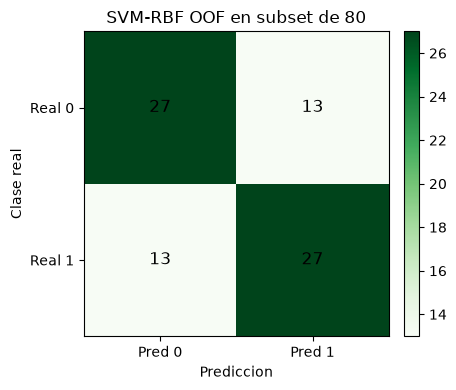

In [10]:
subset_cv_summary, subset_cv_fold_metrics = cross_validate_grid(
    quantum80_raw,
    quantum80_raw[TARGET].astype(int),
    STRICT_FEATURES,
    balance_training=False,
    fold_assignments=quantum80_folds["validation_fold"],
)
subset_cv_summary = subset_cv_summary.sort_values(
    ["f1_mean", "balanced_accuracy_mean", "mcc_mean"], ascending=False
).reset_index(drop=True)
subset_cv_summary.insert(0, "feature_set", STRICT_FEATURE_SET)
subset_cv_summary.insert(1, "n_features", len(STRICT_FEATURES))
subset_cv_summary.insert(2, "features", "|".join(STRICT_FEATURES))

subset_best = subset_cv_summary.iloc[0]
subset_best_fold_metrics, subset_oof_predictions = cross_validated_oof(
    quantum80_raw,
    quantum80_raw[TARGET].astype(int),
    STRICT_FEATURES,
    float(subset_best["C"]),
    subset_best["gamma"],
    balance_training=False,
    fold_assignments=quantum80_folds["validation_fold"],
)
subset_oof_metrics = classification_metrics(
    subset_oof_predictions["y_true"], subset_oof_predictions["y_pred"]
)

subset_cv_summary.to_csv(ARTIFACT_DIR / "quantum80_svm_cv_summary.csv", index=False)
subset_cv_fold_metrics.to_csv(ARTIFACT_DIR / "quantum80_svm_grid_fold_metrics.csv", index=False)
subset_best_fold_metrics.to_csv(ARTIFACT_DIR / "quantum80_svm_best_fold_metrics.csv", index=False)
subset_oof_predictions.to_csv(ARTIFACT_DIR / "quantum80_svm_oof_predictions.csv", index=False)
pd.DataFrame([{**{"feature_set": STRICT_FEATURE_SET, "C": subset_best["C"], "gamma": subset_best["gamma"]}, **subset_oof_metrics}]).to_csv(
    ARTIFACT_DIR / "quantum80_svm_oof_metrics.csv", index=False
)

display(subset_cv_summary[[
    "feature_set", "n_features", "C", "gamma",
    "accuracy_mean", "precision_mean", "recall_mean", "f1_mean",
    "specificity_mean", "balanced_accuracy_mean", "mcc_mean",
]].head(9))

display(pd.DataFrame([{**{"C": subset_best["C"], "gamma": subset_best["gamma"]}, **subset_oof_metrics}])[[
    "C", "gamma", "accuracy", "precision", "recall", "f1", "specificity", "balanced_accuracy", "mcc", "tn", "fp", "fn", "tp"
]])

cm_subset = confusion_matrix(subset_oof_predictions["y_true"], subset_oof_predictions["y_pred"], labels=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(4.8, 4.0))
im = ax.imshow(cm_subset, cmap="Greens")
ax.set_xticks([0, 1], ["Pred 0", "Pred 1"])
ax.set_yticks([0, 1], ["Real 0", "Real 1"])
ax.set_title("SVM-RBF OOF en subset de 80")
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm_subset[i, j]), ha="center", va="center", color="black", fontsize=12)
ax.set_xlabel("Prediccion")
ax.set_ylabel("Clase real")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "quantum80_svm_oof_confusion_matrix.png", dpi=160)
plt.show()

## 8. Resumen ejecutivo de Parte 1 y Parte 2

In [11]:
strict_holdout_row = holdout_metrics.loc[holdout_metrics["feature_set"] == STRICT_FEATURE_SET].iloc[0]
threshold_holdout_row = threshold_audit.query("split == 'holdout' and policy == 'oof_max_f1_threshold'").iloc[0]
subset_row = pd.read_csv(ARTIFACT_DIR / "quantum80_svm_oof_metrics.csv").iloc[0]

summary_md = f'''
### Decisiones para continuar

- **Feature set recomendado:** `{STRICT_FEATURE_SET}` con {len(STRICT_FEATURES)} variables: `{', '.join(STRICT_FEATURES)}`. En CV estricto supera a las 9 variables originales y reduce el costo cuantico potencial de 9 a {len(STRICT_FEATURES)} qubits/features.
- **SVM-RBF estricta en holdout:** `C={STRICT_C:g}`, `gamma={STRICT_GAMMA}`, F1={strict_holdout_row['f1']:.3f}, precision={strict_holdout_row['precision']:.3f}, recall={strict_holdout_row['recall']:.3f}, specificity={strict_holdout_row['specificity']:.3f}.
- **Threshold auditado:** un threshold OOF negativo (`{best_threshold:.3f}`) sube el F1 de holdout a {threshold_holdout_row['f1']:.3f}, pero aumenta falsos positivos a {int(threshold_holdout_row['fp'])}. Esto sirve como benchmark academico, no como regla segura para certificar agua potable.
- **Subconjunto QSVM listo:** 80 filas balanceadas, 40/40 por clase, con 5 folds de 16 filas (8/8). La SVM-RBF local sobre estas mismas 80 filas obtiene F1 OOF={subset_row['f1']:.3f} con `C={subset_row['C']}` y `gamma={subset_row['gamma']}`.

### Archivos generados

Todos los artefactos nuevos quedaron en:

`{ARTIFACT_DIR}`
'''

display(Markdown(summary_md))


### Decisiones para continuar

- **Feature set recomendado:** `chem5_prev` con 5 variables: `Sulfate, ph, Solids, Chloramines, Hardness`. En CV estricto supera a las 9 variables originales y reduce el costo cuantico potencial de 9 a 5 qubits/features.
- **SVM-RBF estricta en holdout:** `C=10`, `gamma=scale`, F1=0.585, precision=0.566, recall=0.605, specificity=0.703.
- **Threshold auditado:** un threshold OOF negativo (`-0.599`) sube el F1 de holdout a 0.609, pero aumenta falsos positivos a 215. Esto sirve como benchmark academico, no como regla segura para certificar agua potable.
- **Subconjunto QSVM listo:** 80 filas balanceadas, 40/40 por clase, con 5 folds de 16 filas (8/8). La SVM-RBF local sobre estas mismas 80 filas obtiene F1 OOF=0.675 con `C=10.0` y `gamma=0.01`.

### Archivos generados

Todos los artefactos nuevos quedaron en:

`C:\Users\johnn\OneDrive\Documentos\Quanthaton\TuQanes\notebooks\Johnny\artifacts_hacia_agua_limpia_partes_1_2`
